## Pre-requisites
To start this programming material with Sentiment Classification with Pretrained Word Embeddings **all students must be aware** of the following concepts:
* Word embeddings
* Basic Python/ pytorch
* Neural Network Architecture

## Learning objective

* To be able to estimate the word embeddings of a small corpus

# Basic Embeding

This code imports the PyTorch library and the vocabulary module from the torchtext package. It also imports the numpy library as np.

In [ ]:
import torch
import torchtext.vocab as vocab
import numpy as np


This code is using pre-trained GloVe (Global Vectors for Word Representation) embeddings to get the vector representation of some words. These embeddings are basically a way to represent words as vectors in a high-dimensional space based on the context in which they appear. This makes it easier to perform natural language processing tasks like sentiment analysis, text classification, and machine translation.

The first line of code loads the GloVe embeddings with a name '6B' and a dimension of 100, and assigns it to the variable glove.

The second line of code defines a list of words that we want to get the vector representations for.

The third line of code gets the vector representation of each word in the list using the glove embeddings. It converts these embeddings into numpy arrays and stores them in a list called word_embeddings.

Finally, the last four lines of code iterate through each word in the words list, printing out the word and its corresponding vector representation in a formatted way using the np.array2string function.

In [ ]:

# Load pre-trained GloVe embeddings
glove = vocab.GloVe(name='6B', dim=100)

# Define some words
words = ['cat', 'dog', 'tree', 'car']

# Get the embeddings for the words
word_embeddings = [glove[word].numpy() for word in words]

# Print the embeddings
for i, word in enumerate(words):
    print(f"{word}: {np.array2string(word_embeddings[i], precision=2, separator=',')}")




In below code


First, the paragraph is defined as a string, and then tokenized into individual words using the lower() and split() methods. Next, the pre-trained GloVe embeddings are used to get the vector representation of each token, which are then stored in a list as numpy arrays.

Finally, the code iterates over each token in the list and prints out the token along with its corresponding vector representation, which is formatted as a string using np.array2string().

In [ ]:
# Define a paragraph
paragraph = "The cat sat in the tree while the dog chased the car."

# Tokenize the paragraph
tokens = paragraph.lower().split()

# Get the embeddings for the tokens
token_embeddings = [glove[token].numpy() for token in tokens]

# Print the embeddings
for i, token in enumerate(tokens):
    print(f"{token}: {np.array2string(token_embeddings[i], precision=2, separator=',')}")

Below Python script that demonstrates how to use pre-trained GloVe embeddings to get the vector representation of a whole sentence.

First, a string paragraph is defined, which contains a sentence about a cat, a tree, a dog, and a car. The paragraph is tokenized into individual words using the lower() and split() methods. The pre-trained GloVe embeddings are then used to get the vector representation of each token, which are stored in a list as numpy arrays.

Next, the mean embedding of all the tokens is calculated by using the np.mean() function with axis=0 argument, which averages the embeddings across all tokens. The result is a single vector representation of the entire sentence, stored in the sentence_embedding variable.

Finally, the code prints out the sentence embedding as a formatted string, using np.array2string() to convert the embedding from a numpy array to a string. The printed string shows the vector representation of the whole sentence that was given as input to the script.

In [ ]:
# Define a paragraph
paragraph = "The cat sat in the tree while the dog chased the car."

# Tokenize the paragraph
tokens = paragraph.lower().split()

# Get the embeddings for the tokens
token_embeddings = [glove[token].numpy() for token in tokens]

# Get the mean embedding of all tokens
sentence_embedding = np.mean(token_embeddings, axis=0)

# Print the sentence embedding
print(f"Sentence embedding of The cat sat in the tree while the dog chased the car. : {np.array2string(sentence_embedding, precision=2, separator=',')}")


In [ ]:
import torch
import torchtext

# The first time you run this will download a ~823MB file
glove = torchtext.vocab.GloVe(name="6B", # trained on Wikipedia 2014 corpus
                              dim=100)    # embedding size = 50

## Word Similarity

Below code is computing the Euclidean distance between the vector representation of the word 'cat' and the vector representations of each word in the list other.

In [ ]:
word = 'cat'
other = ['dog', 'bike', 'kitten', 'puppy', 'kite', 'computer', 'neuron']
for w in other:
    dist = torch.norm(glove[word] - glove[w]) # euclidean distance
    print(w, float(dist))

dog 2.6811304092407227
bike 6.022563457489014
kitten 4.454165935516357
puppy 3.9275598526000977
kite 5.859299659729004
computer 6.960631847381592
neuron 7.568033218383789


Keep in mind that GloVe vectors are trained on word co-occurrences, and so words with similar embeddings will tend to co-occur with other words. For example, "cat" and "dog" tend to occur with similar other words---even more so than "cat" and "kitten" because these two words tend to occur in different contexts!

Lets see more example cose words

In [ ]:
def print_closest_words(vec, n=5):
    dists = torch.norm(glove.vectors - vec, dim=1)     # compute distances to all words
    lst = sorted(enumerate(dists.numpy()), key=lambda x: x[1]) # sort by distance
    for idx, difference in lst[1:n+1]: 					       # take the top n
        print(glove.itos[idx], difference)

print_closest_words(glove["cat"], n=10)



In [ ]:
print_closest_words(glove['doctor'])


physician 3.6094282
nurse 3.818501
patient 4.2201242
dentist 4.2564683
dr. 4.27268


In [ ]:
print_closest_words(glove['black'])


white 3.1696725
blue 3.6949322
gray 3.8342047
red 4.037103
brown 4.1854343


In [ ]:
print_closest_words(glove['engineer'])

technician 4.076519
mechanic 4.221217
engineers 4.318421
contractor 4.514947
pioneer 4.562885


# Semantic Simillarity using GloVe Embedding

## Importing

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
import gensim.downloader as api

This code downloads two resources from the Natural Language Toolkit (NLTK) library:

The first line downloads the list of stopwords for various languages, which are commonly used words that are considered to be of little value in text analysis.

The second line downloads the Punkt tokenizer, which is a pre-trained unsupervised machine learning model used for sentence segmentation (i.e., splitting text into individual sentences).



In [ ]:
import nltk
nltk.download('stopwords')

nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

The `glove `function defined in the code provided has the following steps inside it:

Loads the pre-trained GloVe model using the api.load function from the gensim library.

Loads a set of stop words from the nltk library and a set of punctuation marks from the string library.

Defines a nested function clean_text that takes a sentence as input, tokenizes it, removes stop words and punctuation marks, and returns a list of cleaned tokens.

Initializes an empty list sentence_embeddings to store the GloVe sentence embeddings of each sentence.

Loops over each sentence in the input list, cleans it using the clean_text function, and initializes an empty embedding vector.

Loops over each cleaned token in the sentence, and if the token is in the GloVe model, adds its vector to the embedding vector for the sentence.

Appends the final embedding vector for the sentence to the sentence_embeddings list.

Returns the final sentence embeddings as a NumPy array.

In [ ]:


def glove(sentences):
    glove_model = api.load('glove-wiki-gigaword-50')
    stop_words = set(stopwords.words('english'))
    punctuations = set(string.punctuation)

    def clean_text(text):
        tokens = word_tokenize(text.lower())
        cleaned_tokens = []
        for token in tokens:
            if token not in stop_words and token not in punctuations:
                cleaned_tokens.append(token)
        return cleaned_tokens

    sentence_embeddings = []
    for sentence in sentences:
        cleaned_sentence = clean_text(sentence)
        embedding = np.zeros(glove_model.vector_size)
        for token in cleaned_sentence:
            if token in glove_model:
                embedding += glove_model[token]
        sentence_embeddings.append(embedding)
    return np.array(sentence_embeddings)





The plot_similarity function takes a list of labels and their corresponding feature vectors as input, and plots a heatmap of the cosine similarities between the feature vectors.

The function first computes the inner product (i.e., dot product) of the feature vectors to obtain a correlation matrix corr. It then normalizes the feature vectors and computes the outer product of the norms to obtain a matrix of pairwise norms norms_matrix. The similarity matrix is then computed as the element-wise division of corr by norms_matrix, resulting in a matrix of cosine similarities between the feature vectors.

The function then plots a heatmap of the similarity matrix using the seaborn library, with labels on both axes, and annotates each cell of the heatmap with its corresponding similarity value. The rotation parameter specifies the rotation angle of the x-axis labels in the plot, and vmin and vmax set the minimum and maximum values for the color scale of the heatmap. The title of the plot is set to "Semantic Textual Similarity".

In [ ]:
def plot_similarity(labels, features, rotation):
    corr = np.inner(features, features)
    norms = np.linalg.norm(features, axis=1)
    norms_matrix = np.outer(norms, norms)
    similarity_matrix = corr / norms_matrix
    fig, ax = plt.subplots(figsize=(10,10))
    sns.set(font_scale=1.2)
    g = sns.heatmap(
        similarity_matrix, annot=True,
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=1,
        cmap="YlOrRd")
    g.set_xticklabels(labels, rotation=rotation)
    g.set_title("Semantic Textual Similarity")




The `run_and_plot` function takes a list of text messages as input, computes their GloVe sentence embeddings using the glove function, and then visualizes the pairwise cosine similarities between the message embeddings using the plot_similarity function.

Specifically, the function first calls glove on the input list of messages to obtain their embeddings. It then passes the list of messages and the embeddings to the plot_similarity function, with a rotation angle of 90 degrees for the x-axis labels. The resulting heatmap shows the pairwise similarities between the messages, with each message appearing twice (once on the x-axis and once on the y-axis). The diagonal cells of the heatmap show the self-similarity of each message.

In [ ]:
def run_and_plot(msgs):
    message_embeddings_ = glove(msgs)
    plot_similarity(msgs, message_embeddings_, 90)



The run_and_plot function is called with a list of 12 text messages as input. It computes their GloVe sentence embeddings using the glove function, and then visualizes the pairwise cosine similarities between the message embeddings using the plot_similarity function.

The resulting heatmap shows the pairwise similarities between the messages, with each message appearing twice (once on the x-axis and once on the y-axis). The diagonal cells of the heatmap show the self-similarity of each message.

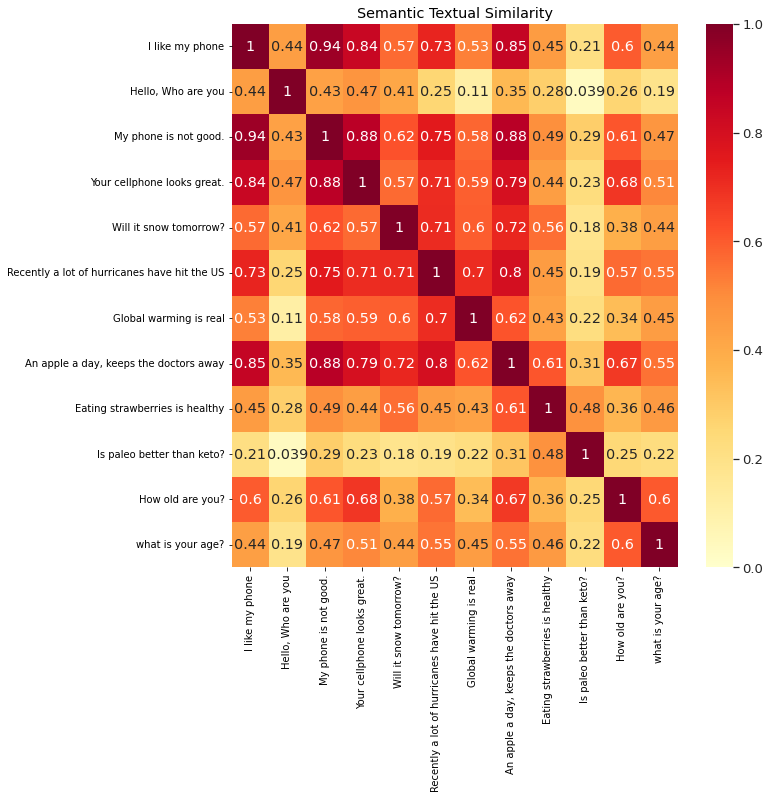

In [ ]:
messages = [
    "I like my phone",
    "Hello, Who are you",
    "My phone is not good.",
    "Your cellphone looks great.",
    "Will it snow tomorrow?",
    "Recently a lot of hurricanes have hit the US",
    "Global warming is real",
    "An apple a day, keeps the doctors away",
    "Eating strawberries is healthy",
    "Is paleo better than keto?",
    "How old are you?",
    "what is your age?",
]

run_and_plot(messages)

# References

* [GloVe: Global Vectors for Word Representation](https://aclanthology.org/D14-1162.pdf)